# Práctica 10 - Proporciones

### Carlos Emiliano Mendoza Hernández

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [3]:
def set_style():
    """Define el estilo profesional para las gráficas."""
    plt.style.use('tableau-colorblind10') # Estilo de Tableau
    sns.set_style("whitegrid")  # Fondo blanco con grid
    plt.rcParams['figure.figsize'] = (8, 5)  # Tamaño por defecto
    plt.rcParams['font.size'] = 12  # Tamaño de fuente base
    plt.rcParams['font.family'] = 'DejaVu Sans'  # Fuente (cambia a una instalada en tu sistema)
    plt.rcParams['axes.titlesize'] = 14  # Título de la gráfica
    plt.rcParams['axes.labelsize'] = 12  # Etiquetas de ejes
    plt.rcParams['xtick.labelsize'] = 10  # Ticks del eje X
    plt.rcParams['ytick.labelsize'] = 10  # Ticks del eje Y
    plt.rcParams['axes.spines.top'] = False  # Eliminar borde superior
    plt.rcParams['axes.spines.right'] = False  # Eliminar borde derecho
    plt.rcParams['grid.alpha'] = 0.3  # Transparencia del grid

set_style()

In [4]:
df = pd.read_csv('SCN_DS_11042024021149683.csv')

income_groups = [
    'Small Island Developing States',
    'Least Developed Countries',
    'Lower middle income countries',
    'Upper middle income countries',
    'High income countries',
    'Middle income countries',
    'Low income countries',
    'Landlocked Developing Countries'
]

def classify_type(row):
    if row['LOCATION'].isalpha() and len(row['LOCATION']) == 3:
        return 'C'
    elif row['Country'] in income_groups:
        return 'I'
    else:
        return 'R'

df['Type'] = df.apply(classify_type, axis=1)
df = df[['INDICATOR', 'Indicator', 'LOCATION', 'Country', 'Type', 'TIME', 'Value']].rename(columns={
    'INDICATOR': 'Indicator Code',
    'Indicator': 'Indicator Name',
    'LOCATION': 'Geo Code',
    'Country': 'Geo Name',
    'TIME': 'Year',
    'Value': 'Value'
})
df.to_csv('cyt.csv', index=False)

1. Realice un informe del gasto en Ciencia y Tecnología (CyT) a nivel mundial entre los años 2016 y 2021, basado en la información proporcionada por el UNESCO Institute for Statistics (UIS) y contenida en el archivo *SCN_DS_11042024021149683.csv*. El informe deberá contestar las siguientes preguntas ocupando al menos 5 tipos de gráficos distintos para mostrar las proporciones pedidas.

#### **¿Cómo se comporta el gasto en CyT en el mundo si agrupamos por regiones geográficas?**

In [5]:
df_gasto_region = df[
    (df['Indicator Code'] == 'EXPGDP_TOT') &
    ((df['Type'] == 'R')) &
    (df['Geo Name'] != 'World') &
    (df['Year'].between(2016, 2021))
].copy()

df_gasto_region = df_gasto_region.drop_duplicates(subset=['Geo Name', 'Year'], keep='first')

pivot = df_gasto_region.pivot(index='Geo Name', columns='Year', values='Value')
pivot['Average'] = pivot.mean(axis=1)
pivot.sort_values('Average', ascending=False, inplace=True)
pivot.drop(columns='Average', inplace=True)

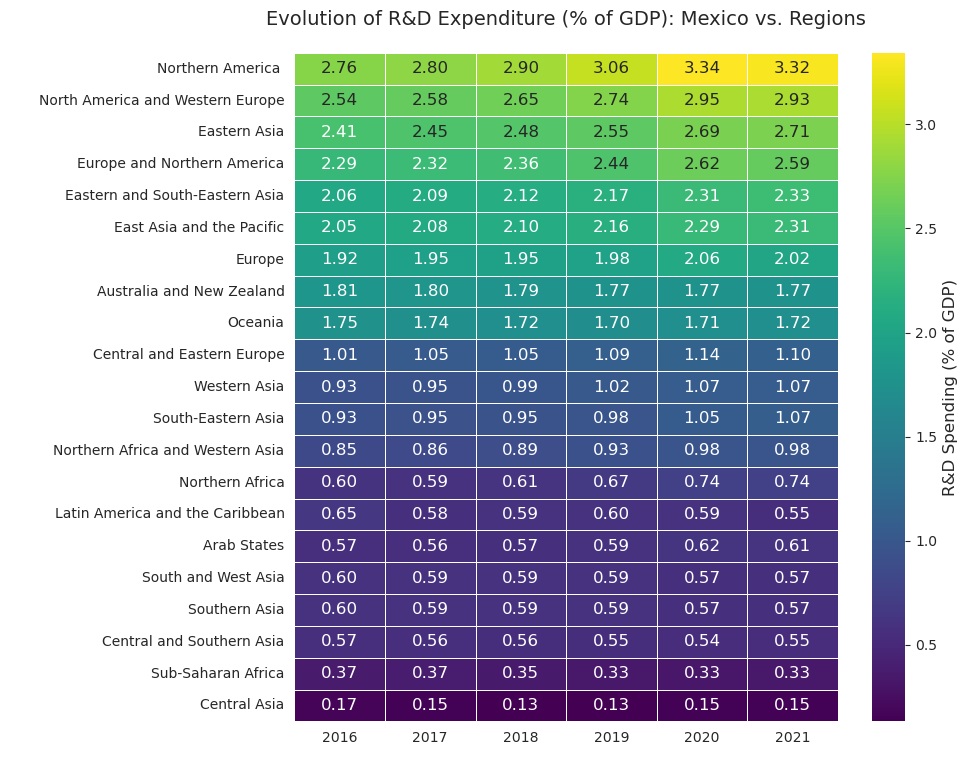

In [6]:
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    data = pivot,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'R&D Spending (% of GDP)'}
)

for label in ax.get_yticklabels():
    if label.get_text() == 'Mexico':
        label.set_weight('bold')
        label.set_color('red')

plt.title('Evolution of R&D Expenditure (% of GDP): Mexico vs. Regions', pad=20)
plt.xlabel(' ', labelpad=10)
plt.ylabel(' ', labelpad=10)

plt.tight_layout()
plt.show()

Podemos ver que la región de América del Norte es la que más gasta en CyT, seguida de Europa y Asia Oriental. La tendencia indica que estas regiones han ido aumentando el porcentaje de gasto en CyT a lo largo de los años. Por otra parte, Asia Central y Africa y el Sur de Asia son las regiones que menos gastan en CyT, y no han mostrado un aumento en su gasto a lo largo de los años. En general, el gasto en CyT no ha disminuido en ninguna region, pero la diferencia entre las regiones más ricas y las más pobres sigue siendo significativa.

#### **¿Cómo se comporta el gasto en CyT en el mundo si agrupamos por tipo de ingreso?**

In [7]:
df_gasto_ingreso = df[(df["Type"] == "I") & (df["Indicator Code"] == "EXPGDP_TOT")]

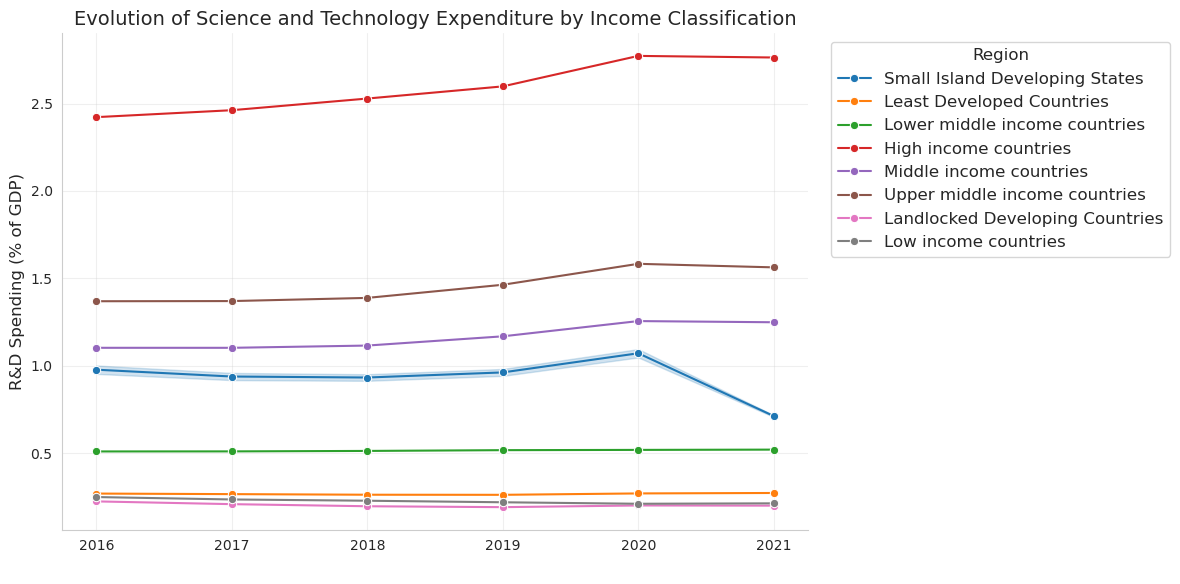

In [8]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_gasto_ingreso,
    x="Year",
    y="Value",
    hue="Geo Name",
    marker="o",
    palette="tab10"
)

plt.title("Evolution of Science and Technology Expenditure by Income Classification")
plt.xlabel(" ")
plt.ylabel("R&D Spending (% of GDP)")
plt.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Como es de esperarse, los paises con ingreso alto son los que más gastan en CyT, seguidos de los paises de ingreso medio alto y medio bajo. Los paises de ingreso bajo son los que menos gastan en CyT, y su gasto ha permanecido relativamente constante a lo largo de los años. En general, el gasto en CyT en los paises mas desarrollados ha ido aumentando, haciendo la diferencia entre los paises ricos y pobres mas significativa.

#### **¿Cómo es el gasto en CyT de México comparado con el resto del mundo si agrupamos a los países por regiones geográficas?**

In [9]:
df_mexico_vs_region = df[
    (df['Indicator Code'] == 'EXPGDP_TOT') &
    ((df['Geo Name'] == 'Mexico') | (df['Type'] == 'R')) &
    (df['Geo Name'] != 'World') &
    (df['Year'].between(2016, 2021))
].copy()

df_mexico_vs_region = df_mexico_vs_region.drop_duplicates(subset=['Geo Name', 'Year'], keep='first')

pivot_data = df_mexico_vs_region.pivot(index='Geo Name', columns='Year', values='Value')
pivot_data['Average'] = pivot_data.mean(axis=1)
pivot_data.sort_values('Average', ascending=False, inplace=True)
pivot_data.drop(columns='Average', inplace=True)

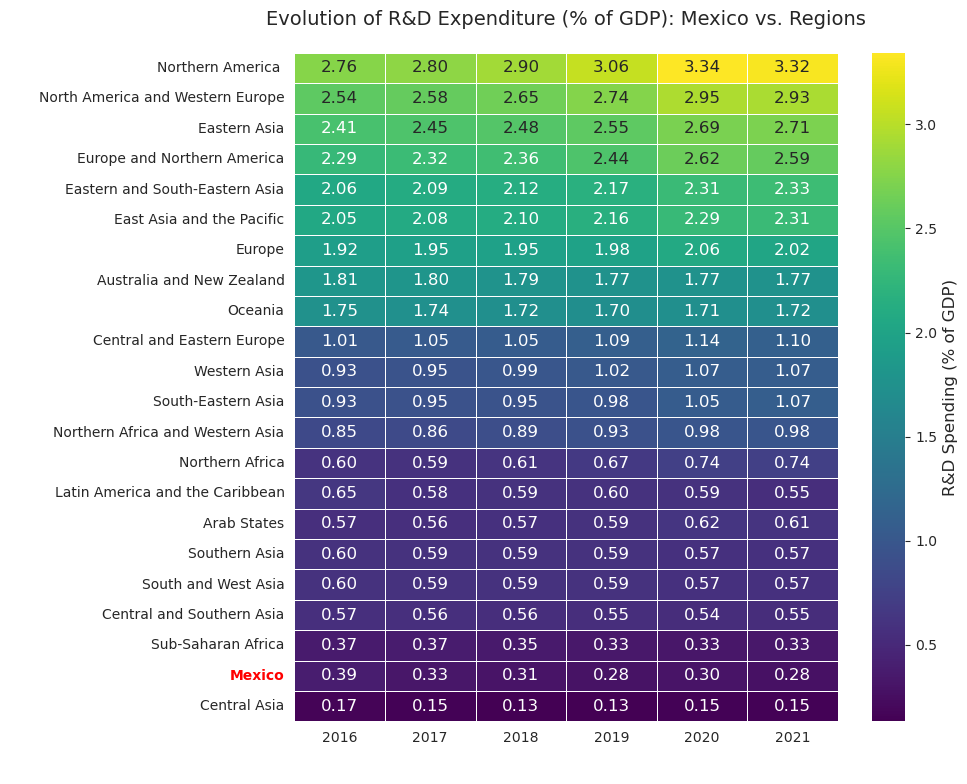

In [10]:
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'R&D Spending (% of GDP)'}
)

for label in ax.get_yticklabels():
    if label.get_text() == 'Mexico':
        label.set_weight('bold')
        label.set_color('red')

plt.title('Evolution of R&D Expenditure (% of GDP): Mexico vs. Regions', pad=20)
plt.xlabel(' ', labelpad=10)
plt.ylabel(' ', labelpad=10)

plt.tight_layout()
plt.show()

Mexico no ha invertido mas del 40% de su PIB desde, al menos, 2016. En general, el gasto en CyT de Mexico es bajo comparado con el resto del mundo, y ha mostrado un decremento significativo a lo largo de los años. La tendencia indica que Mexico no ha podido aumentar su gasto en CyT, ubicandose unicamente por encima de Asia Central.

#### **¿Cómo es el gasto en CyT de México comparado con el resto del mundo si agrupamos a los países por tipo de ingreso?**

In [11]:
df_mexico_vs_income = df[
    (df['Indicator Code'] == 'EXPGDP_TOT') &
    ((df['Geo Name'] == 'Mexico') | (df['Type'] == 'I')) &
    (df['Year'].between(2016, 2021))
].copy()

df_mexico_vs_income = df_mexico_vs_income.drop_duplicates(subset=['Geo Name', 'Year'], keep='first')

pivot_data_2 = df_mexico_vs_income.pivot(index='Geo Name', columns='Year', values='Value')
pivot_data_2['Average'] = pivot_data_2.mean(axis=1)
pivot_data_2.sort_values('Average', ascending=False, inplace=True)

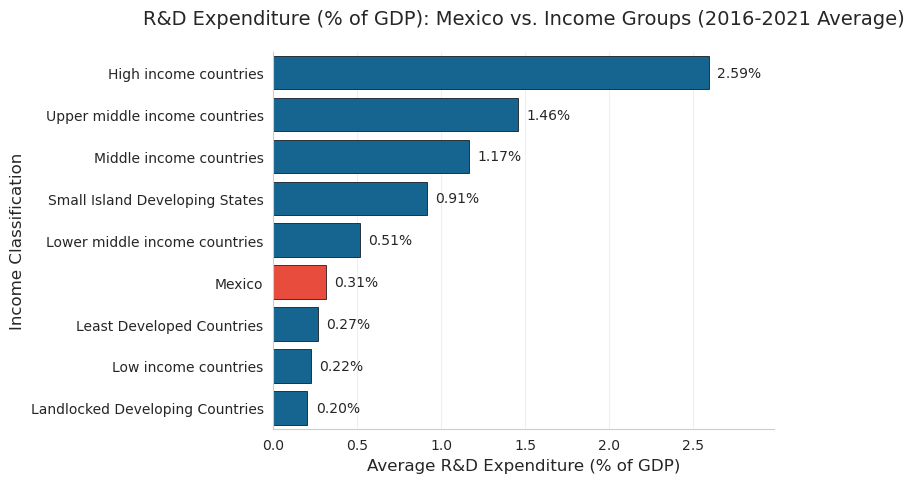

In [12]:
ax = sns.barplot(
    y=pivot_data_2.index,
    x=pivot_data_2['Average'],
    edgecolor='black',
    linewidth=0.5
)

mexico_idx = list(pivot_data_2.index).index('Mexico')
ax.patches[mexico_idx].set_color('#e74c3c')
ax.patches[mexico_idx].set_edgecolor('black')

for i, (name, row) in enumerate(pivot_data_2.iterrows()):
    value = row['Average']
    ax.text(value + 0.05, i, f'{value:.2f}%', va='center', fontsize=10)

plt.title('R&D Expenditure (% of GDP): Mexico vs. Income Groups (2016-2021 Average)', pad=20)
plt.xlabel('Average R&D Expenditure (% of GDP)')
plt.ylabel('Income Classification')
plt.xlim(0, pivot_data_2['Average'].max() * 1.15)

plt.tight_layout()
plt.show()

Mexico solo ha podido superar a los paises menos desarrollados y a los de menores ingresos, lo cual sugiere que Mexico no invierte lo suficiente en CyT dada su posición como un país de ingreso medio alto.

#### **¿Cómo es el gasto en CyT de México comparado con el de América Latina y el Caribe?**

In [13]:
df_compare = df[
    (df['Indicator Code'] == 'EXPGDP_TOT') &
    (df['Geo Name'].isin(['Mexico', 'Latin America and the Caribbean'])) &
    (df['Year'].between(2016, 2021))
].copy()
df_compare = df_compare.drop_duplicates(subset=['Geo Name', 'Year'], keep='first')

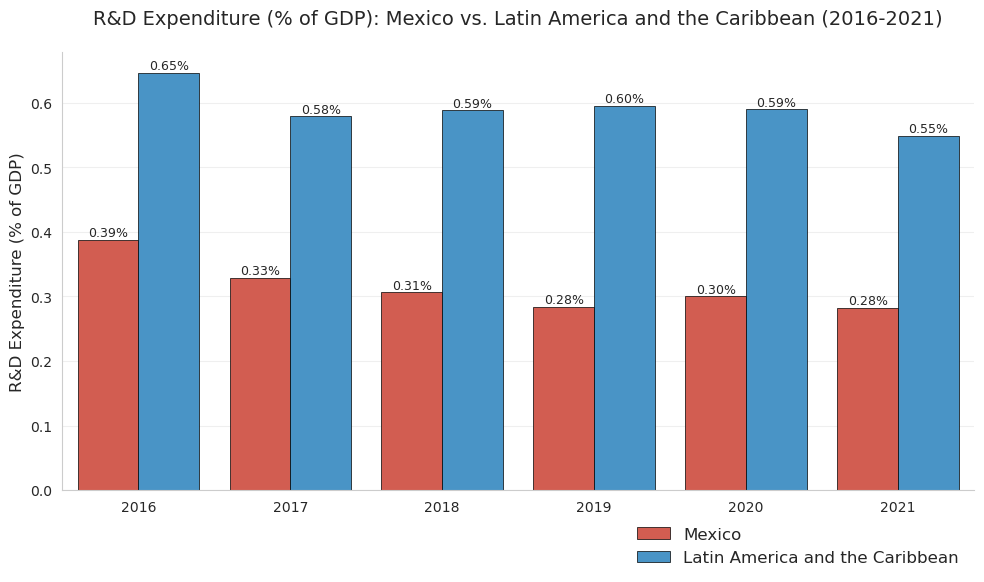

In [14]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_compare,
    x='Year',
    y='Value',
    hue='Geo Name',
    palette=['#e74c3c', '#3498db'],
    edgecolor='black',
    linewidth=0.5
)

plt.title('R&D Expenditure (% of GDP): Mexico vs. Latin America and the Caribbean (2016-2021)', pad=20)
plt.ylabel('R&D Expenditure (% of GDP)')
plt.xlabel('')
plt.legend(title='', frameon=False, bbox_to_anchor=(1, -0.05))
for p in ax.patches:
    if p.get_height() > 0:
        va = 'center'
        y_offset = 5
        if p.get_facecolor() == (0.9058823529411765, 0.2980392156862745, 0.23529411764705882, 1.0):  # Color RGB de México
            va = 'bottom'
            y_offset = 3
        
        ax.annotate(
            f'{p.get_height():.2f}%',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va=va,
            xytext=(0, y_offset),
            textcoords='offset points',
            fontsize=9
        )

plt.tight_layout()
plt.show()

A nivel region, Mexico tampoco supera el porcentaje de gasto en CyT de America Latina y el Caribe.

#### **¿Cómo se compara el gasto en CyT de Norte América, Europa Occidental así como del Este de Asia y el Pacifico con el resto del mundo?**

In [15]:
regiones_clave = ['World', 'North America and Western Europe', 'East Asia and the Pacific']
df_radar = df[
    (df['Indicator Code'] == 'EXPGDP_TOT') & 
    (df['Geo Name'].isin(regiones_clave)) &
    (df['Year'].between(2016, 2021))
]

df_radar = df_radar.drop_duplicates(subset=['Geo Name', 'Year'], keep='first').pivot(index='Year', columns='Geo Name', values='Value')

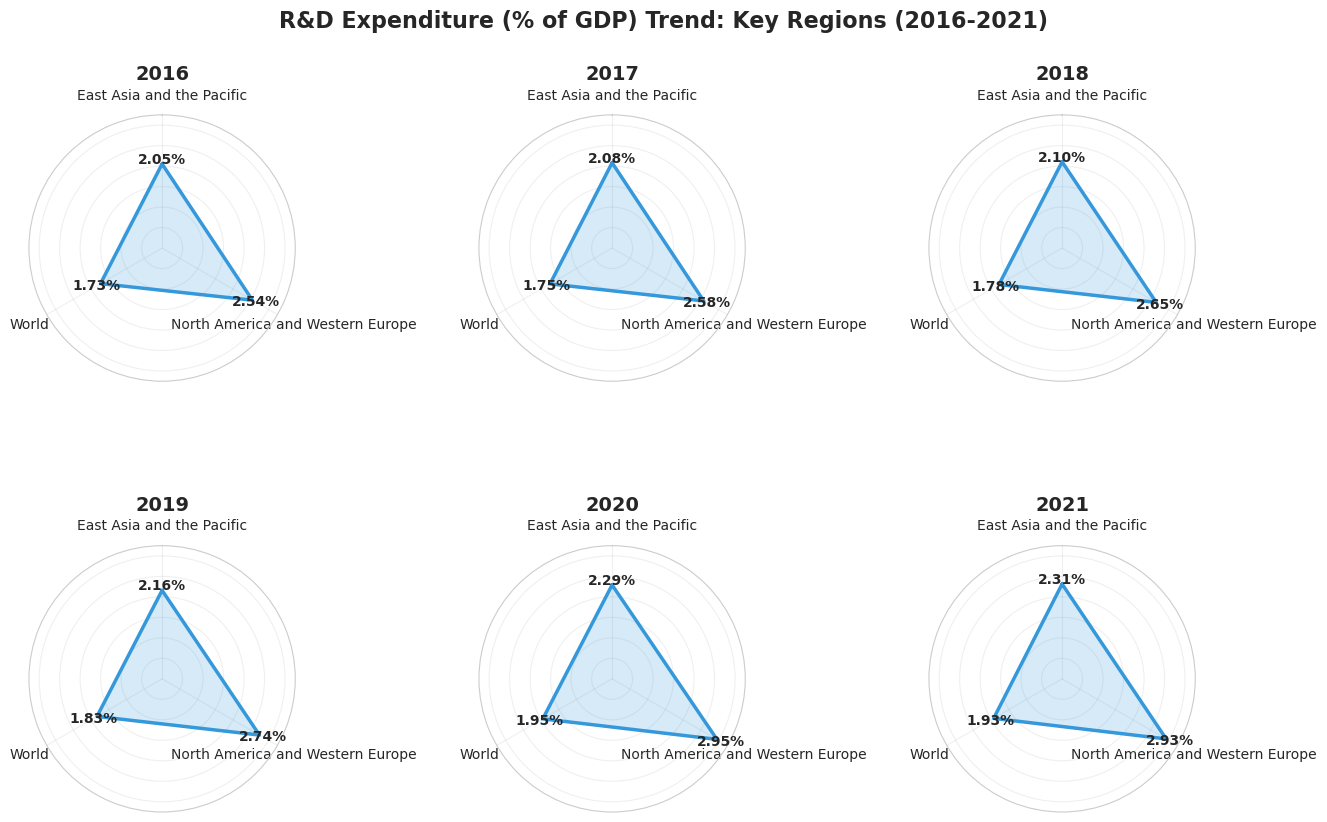

In [16]:
years = df_radar.index.unique()
n_years = len(years)
categories = df_radar.columns.tolist()
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(14, 10))
fig.suptitle('R&D Expenditure (% of GDP) Trend: Key Regions (2016-2021)', 
             y=0.9, fontsize=16, fontweight='bold')

for idx, year in enumerate(years, 1):
    ax = fig.add_subplot(2, 3, idx, polar=True)
    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    plt.xticks(angles[:-1], categories, fontsize=10)
    plt.ylim(0, df_radar.max().max()*1.1)
    ax.set_yticklabels([])
    ax.grid(True, alpha=0.3)
    
    values = df_radar.loc[year].tolist()
    values += values[:1]
    
    ax.plot(angles, values, color='#3498db', linewidth=2.5)
    ax.fill(angles, values, color='#3498db', alpha=0.2)
    
    # Etiquetas de valores
    for angle, val, cat in zip(angles[:-1], values[:-1], categories):
        ax.text(angle, val+0.1, f'{val:.2f}%', 
                ha='center', va='center', 
                fontsize=10, fontweight='bold')
    ax.set_title(f'{year}', pad=25, fontsize=14, fontweight='bold')

plt.tight_layout(pad=3.0)
plt.show()

Estas dos regiones superan el porcentaje mundial de gasto en CyT, lo cual tiene sentido dado que son las regiones más desarrolladas del mundo.